In [1]:
import json
import plotly.graph_objs as go
import matplotlib.pyplot as plt
import logomaker as lm
import pandas as pd
import numpy as np
from fuzzywuzzy import process as fwprocess

In [2]:
with open("data/substrates_data.json") as f:
    # output file from preprocess_data.py
    substrates_data = json.load(f)

with open("data/ppm.json") as f:
    # output file from ppm-pssm.py
    ppm_data = json.load(f)

with open("data/pssm.json") as f:
    # output file from ppm-pssm.py
    pssm_data = json.load(f)

with open("data/pssm_dataset.json") as f:
    # output file from ppm-pssm.py
    pssm_dataset_data = json.load(f)

with open("data/pssm_protease.json") as f:
    # output file from ppm-pssm.py
    pssm_protease_data = json.load(f)

with open("data/scored_substrates_biopython.json") as f:
    # output file from score_substrate_similarities_biopython.py
    substrate_similarities_biopython = json.load(f)

with open("data/scored_substrates_positionwise.json") as f:
    # output file from score_substrate_similarities_biopython.py
    substrate_similarities_positionwise = json.load(f)

In [3]:
def plot_substrates_counts(d):
    """
    Function to plot the number of substrate sequences in an interactive graph
    """
    # Dictionary where each key is a protease and each value is the number of
    # substrate sequences
    counts = {key: len(value) for key, value in d.items()}
    # Sort by most to least substrates
    sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
    # Set up the plot
    fig = go.Figure(data=[go.Bar(x=[item[0] for item in sorted_counts],
                                 y=[item[1] for item in sorted_counts])])
    fig.update_layout(
        title="Number of Substrates for each Protease",
        xaxis_title="Protease",
        yaxis_title="Count",
        yaxis_type="log"
    )
    fig.show()


def plot_substrate_similarities(d):
    """
    Function to plot the similarity score of each protease's substrates based on
    score_substrate_similarities_biopython.py
    """
    # Split the two inner dictionaries
    proteases_with_one_substrate = d["Proteases with only one substrate"]
    proteases_with_many_substrates = d["Proteases with more than one substrate"]
    # Make them lists of tuples where each tuple is a pari od protease name and score
    proteases_with_many_substrates = sorted(
        proteases_with_many_substrates.items(), key=lambda x: x[1], reverse=True)
    proteases_with_one_substrate = [(protease, 1)
                                    for protease in proteases_with_one_substrate]
    # Assign 1 to proteases with only one substrate sequence, as 1 is the largest score possible
    all_dat = proteases_with_one_substrate + proteases_with_many_substrates
    # Color the proteases that have one substrate sequence red, the others blue
    colors = ["red"] * len(proteases_with_one_substrate) + \
        ["blue"] * len(proteases_with_many_substrates)
    # Set up the plot
    fig = go.Figure(data=[go.Bar(x=[item[0] for item in all_dat],
                                 y=[item[1] for item in all_dat],
                                 marker_color=colors)])
    fig.update_layout(
        title="Similarity score for each protease's substrates",
        xaxis_title="Protease",
        yaxis_title="Normalized score"
    )
    fig.show()


def heat_map(ppm, protease_name):
    """
    Function to plot a heatmap of a selected protease's substrate sequence,
    based on a specific matrix (ppm, pssm etc)
    """
    # Extract keys (amino acids) and values (probabilities)
    amino_mappings = {"*": "gap", "X": "Xaa", "A": "Ala", "R": "Arg", "N": "Asn",
                      "D": "Asp", "C": "Cys", "Q": "Gln", "E": "Glu", "G": "Gly",
                      "H": "His", "I": "Ile", "L": "Leu", "K": "Lys", "M": "Met",
                      "F": "Phe", "P": "Pro", "S": "Ser", "T": "Thr", "W": "Trp",
                      "Y": "Tyr", "V": "Val"}
    ppm = {amino_mappings[k]: v for k, v in ppm.items()}
    ppm = sorted(ppm.items(), key=lambda x: x[0])
    ppm = {y[0]: y[1] for y in ppm}
    amino_acids = list(ppm.keys())
    probabilities = list(ppm.values())
    # Convert probabilities to a 2D numpy array
    probabilities_array = np.array(probabilities)
    # Plot using imshow
    plt.figure(figsize=(12, 8))
    plt.imshow(probabilities_array, cmap="cool",
               interpolation="nearest", aspect="auto")
    # Customize
    plt.xticks(np.arange(len(probabilities_array[0])), np.arange(
        1, len(probabilities_array[0]) + 1))
    plt.title(f"Sequence Logo for\n{protease_name}", fontsize=18)
    plt.xlabel("Position")
    plt.ylabel("Amino Acid")
    plt.yticks(np.arange(len(amino_acids)), amino_acids)
    plt.colorbar(label="Probability")
    plt.show()


def logo_plot(data, protease_name):
    """
    Function to plot a logo plot of a selected protease's substrate sequence,
    based on a specific matrix (ppm, pssm etc)
    """
    # Convert to Data Frame (needed for logomaker)
    df = pd.DataFrame(data)
    # Create the logo and customize
    logo = lm.Logo(df, figsize=(12, 8), color_scheme="chemistry", flip_below=False, vpad=0.1)
    logo.ax.set_title(f"Sequence Logo for {protease_name}", fontsize=18)
    positions = ["P1", "P2", "P3", "P4", "P4'", "P3'", "P2'", "P1'"]
    logo.ax.set_xticks(range(len(positions)))
    logo.ax.set_xlabel("Position", fontsize=14)
    logo.ax.set_xticklabels(positions)
    logo.ax.axvline(3.5, color="r", linewidth=2.5, linestyle=":")
    plt.show()


def fuzzy_match_protease(input_protease, data):
    """
    Fuzzy search, captures protease name even with slight typos
    and warns user in case of multiple matches
    """
    all_names = list(data.keys())
    if input_protease in all_names:  # check for exact match
        return input_protease, None
    matched_proteases_with_scores = fwprocess.extract(
        input_protease, all_names)  # check for partial matches
    threshold_score = 90
    close_matches = [
        match for match in matched_proteases_with_scores if match[1] >= threshold_score]
    if len(close_matches) == 1:
        return close_matches[0][0], None
    elif len(close_matches) > 1:
        matched_proteases = [match[0] for match in close_matches]
        print("Multiple matching proteases found:")
        for match in close_matches:
            print(match[0])
        return None, matched_proteases
    else:
        return None, None

In [4]:
plot_substrates_counts(substrates_data)

In [5]:
plot_substrate_similarities(substrate_similarities_biopython)
plot_substrate_similarities(substrate_similarities_positionwise)

The protease 'African swine fever virus processing peptidase' has 6 substrates


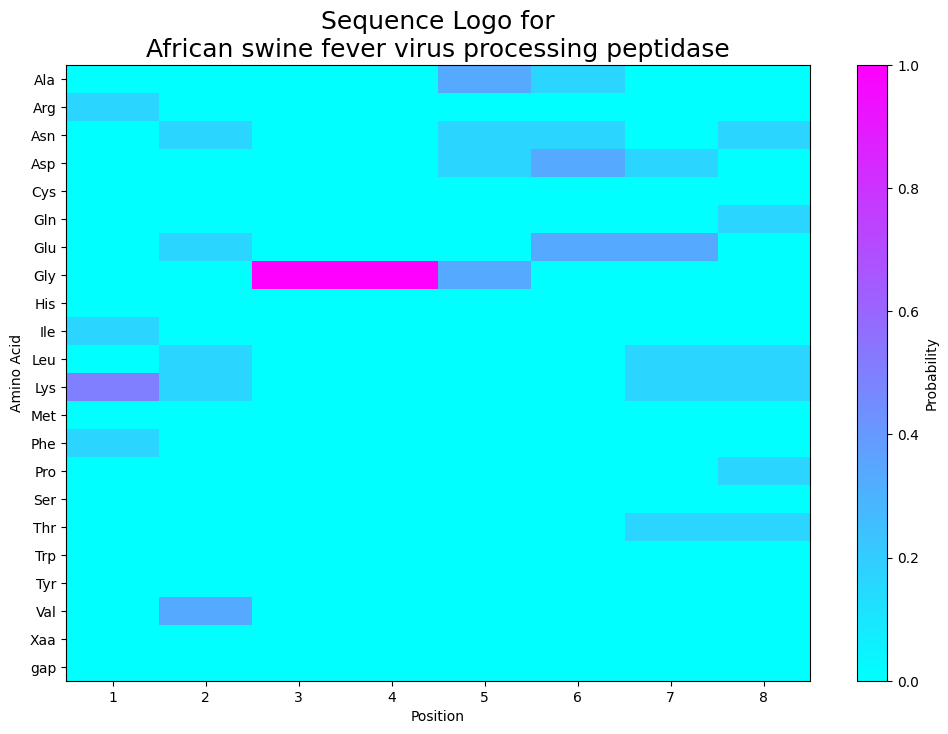

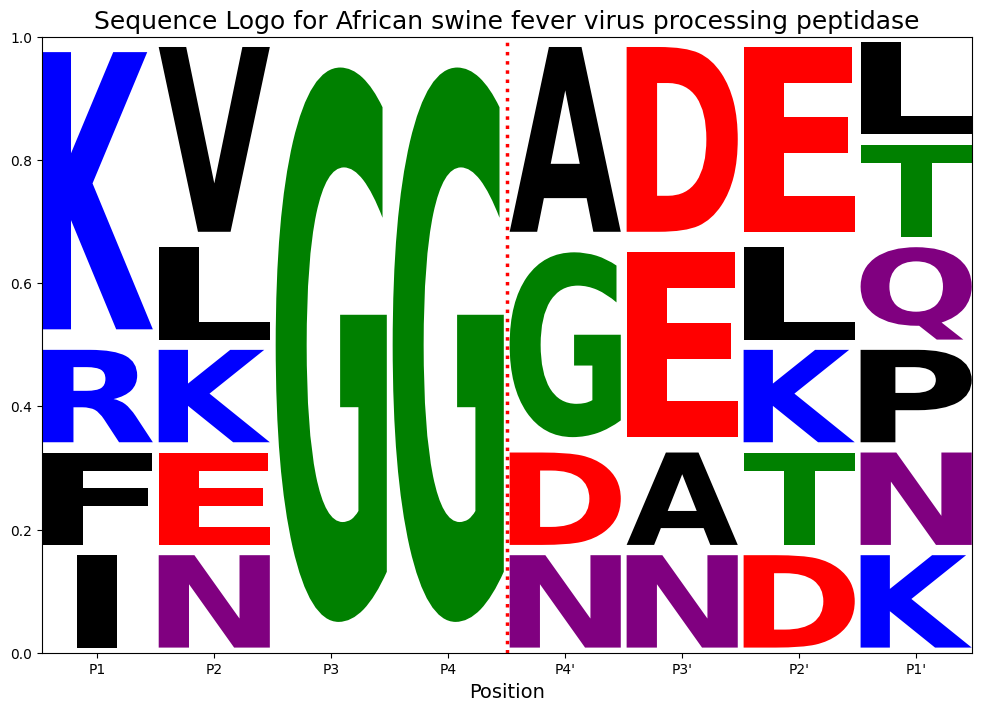

In [6]:
################ define ################
protease_name = "african swine fever"
matrix = ppm_data
########################################

matched_protease, matched_proteases = fuzzy_match_protease(protease_name, matrix)

if matched_protease:
    protease_to_check = matched_protease
    print(f"The protease '{protease_to_check}' has {len(substrates_data[protease_to_check])} substrates")
    heat_map(matrix[protease_to_check], protease_to_check)
    logo_plot(matrix[protease_to_check], protease_to_check)
elif matched_proteases:
    print("Please specify.")
else:
    print("No matching protease found.")